# Climatic and Groundwater Data Overview

In [1]:
import numpy as np
import pandas as pd
# import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import requests
import zipfile
import io

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# from shapely.geometry import Point
# from pyproj import Geod
# from matplotlib.patches import FancyArrow, Rectangle

In [2]:
# since the .csv is large (>100 Mb) we download and read zip

# Google Drive file ID (from your original URL)
file_id = "11TvlNdqSQv6PPooHwt7f9A68Ibz1sQIU"

# Direct download link for Google Drive
zip_url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Download and extract the ZIP file
response = requests.get(zip_url)
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Assume there's only one file in the ZIP
        file_name = z.namelist()[0]
        with z.open(file_name) as f:
            df = pd.read_csv(f)
else:
    print("Failed to download the ZIP file.")
df.head()

/tmp/ipython-input-2044147778.py:16: DtypeWarning: Columns (6,38,42) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


,date,well_no,precipitation_mm_eobs,temperature_C_eobs,actual_evapotranspiration_mm_gleam,potential_evapotranspiration_mm_gleam,site,local_ID,altitude_ m_asl,gw_level_m_asl,...,top_of_screen,bottom_of_screen,geometry,date_left,index_right,lat,lon,date_right,tws_mm_tavg_gldas,gws_mm_tavg_gldas
0,1950-01-01,LT_193,0.0,-8.88,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (24.619946942916 56.197237383388),NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1950-01-01,LT_202,0.0,-8.88,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (24.620043179747 56.197209951771),NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1950-01-01,LT_216,0.0,-8.75,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (24.692295330589 56.205279710082),NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1950-01-01,LT_218,0.0,-8.75,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (24.697801139013 56.21381864295),NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1950-01-01,LT_220,0.0,-8.75,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,POINT (24.69305907439 56.20920104507),NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['date', 'well_no', 'precipitation_mm_eobs', 'temperature_C_eobs',
       'actual_evapotranspiration_mm_gleam',
       'potential_evapotranspiration_mm_gleam', 'site', 'local_ID',
       'altitude_ m_asl', 'gw_level_m_asl', 'gw_level_ m_below_ground',
       'site_id', 'site_name', 'country', 'observation_start_date',
       'observation_end_date', 'well_installataion_date', 'depth_m',
       'local_geo_index', 'standard_geo_index', 'regional_stage',
       'aquifer_type', 'lithology', 'aquifer_top_m_from_land_surface',
       'aquifer_bottom_m_from_land_surface', 'thickness',
       'hydraulic_conductivity_md', 'drawdown', 'debit', 'comp_debit',
       'address', 'WGS_lat', 'WGS_lon', 'land_surface_elevation_m',
       'gw_level_m_from_land_surface', 'top_of_screen', 'bottom_of_screen',
       'geometry', 'date_left', 'index_right', 'lat', 'lon', 'date_right',
       'tws_mm_tavg_gldas', 'gws_mm_tavg_gldas'],
      dtype='object')

### Groundwater Level Timeries

Evaluating groundwater level time series (hydrographs) is a crucial first step before performing any further analysis, because the quality and reliability of conclusions depend directly on the integrity of the input data.
* Data integrity check: Ensures that the groundwater level record is accurate and free from logging or measurement errors before further analysis.

* Identify missing data: Gaps in the time series can bias trends, statistical summaries, and model calibration if not addressed.

* Spot unusual extremes: Detects abnormal peaks or drops, distinguishing between natural events (floods, droughts) and artificial influences (maintenance, pumping tests).

* Establish a sound baseline: Creates confidence that subsequent interpretations and decisions are based on robust, quality-controlled information.

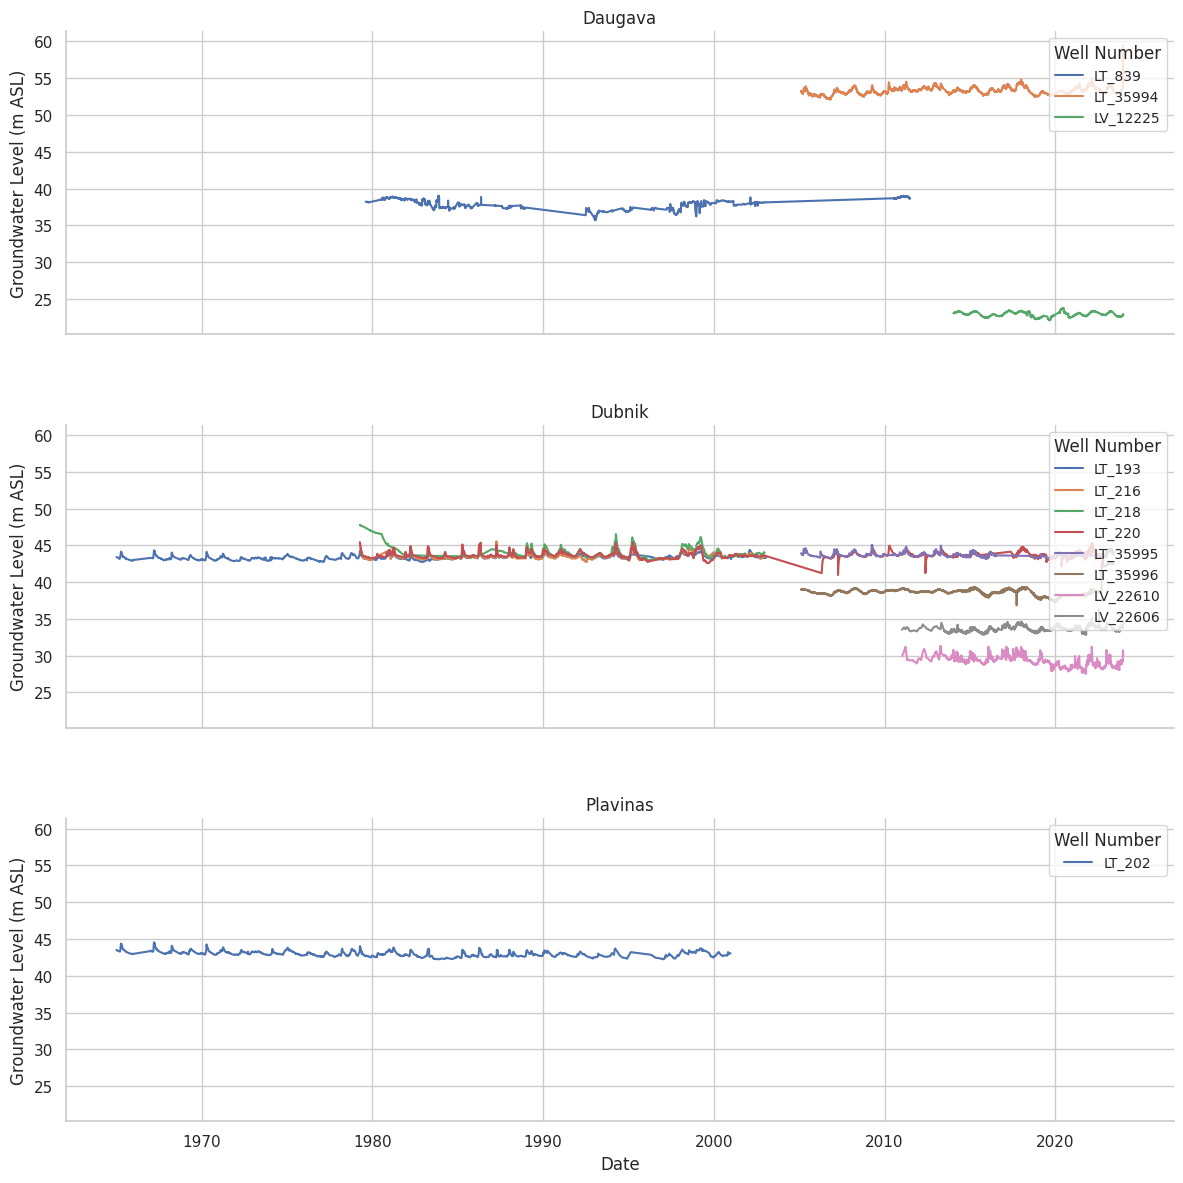

In [ ]:
# Ensure date column is in datetime format
df['date'] = pd.to_datetime(df['date'])

# Create a copy to preserve the original DataFrame
df_grouped = df.copy()

# Define custom order
stage_order = ['Daugava', 'Dubnik', 'Plavinas']

# Set Seaborn style
sns.set(style="whitegrid")

# Create a vertically stacked FacetGrid by regional_stage
g = sns.FacetGrid(
    df_grouped,
    row="regional_stage",
    row_order=stage_order,
    height=4,
    aspect=3,
    sharex=True,
    sharey=True
)

# Plot lines
g.map_dataframe(sns.lineplot, x="date", y="gw_level_m_asl", hue="well_no")

# Add a separate legend to each axis
for ax in g.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    # Only add legend if there are handles
    if handles:
        ax.legend(
            handles, labels, title="Well Number",
            loc='upper right', bbox_to_anchor=(1, 1),
            frameon=True, fontsize='small', title_fontsize='medium'
        )

# Customize plot appearance
g.set_axis_labels("Date", "Groundwater Level (m ASL)")
g.set_titles(row_template="{row_name}")
g.fig.subplots_adjust(hspace=0.3)

# Show plot
plt.show()


### Interpretation

Missing data and interpolation artifacts:
* In all three sites (Daugava, Dubnik, Plavinas), there are segments where a straight line connects two distant points in time. This indicates large data gaps that were connected in plotting, not true continuous measurements. These gaps make direct time-series analysis unreliable without proper gap-filling or handling.

Signal spikes and anomalies:
* In Dubnik (especially wells LT_216, LT_218, LT_220), there are sharp, unrealistic spikes. These are likely caused by short-term disturbances during maintenance, equipment calibration, or temporary measurement errors, not actual groundwater fluctuations. They should be identified and removed before analysis.

Outdated data for ML purposes:
* Several wells (e.g., LT_202 in Plavinas, LT_193 in Dubnik, LT_839 in Daugava) contain long records before 2003. Since groundwater storage (GWStorage) and evapotranspiration data are only available from 2003 onward, these older records cannot be used directly in machine learning models that require those predictors.

Wells to discard:
* Wells with most of their data prior to 2003, or with large gaps and frequent anomalies, will need to be excluded from the ML dataset to ensure model quality and avoid introducing bias from incomplete predictor variables.

Quality control necessity:
* The plots clearly show why preliminary evaluation is essential — without filtering out missing data, spikes, and unsuitable periods, any derived trends or model training could lead to false conclusions.

### Climate Parameters


Precipitation (mm) – precipitation_mm_eobs

* Description: Daily total rainfall and snowfall converted to liquid water equivalent (millimeters). Represents the direct atmospheric water input to the catchment.

* Source: E-OBS (European high-resolution gridded climate dataset), which compiles quality-controlled station data into a spatially consistent grid.

Temperature (°C) – temperature_C_eobs

* Description: Daily mean air temperature at 2 m above ground. Important for understanding seasonal changes, snowmelt timing, and evapotranspiration potential.

* Source: E-OBS dataset, which interpolates observations from multiple European meteorological stations.

Actual Evapotranspiration (mm) – actual_evapotranspiration_mm_gleam

* Description: The combined actual water loss from soil evaporation, plant transpiration, and open water evaporation, constrained by available soil moisture.

* Source: GLEAM (Global Land Evaporation Amsterdam Model), which uses satellite observations, reanalysis meteorology, and land-surface modeling to estimate actual evapotranspiration.

Potential Evapotranspiration (mm) – potential_evapotranspiration_mm_gleam

* Description: The atmospheric demand for water loss through evaporation and transpiration under conditions of unlimited water supply, primarily driven by radiation, temperature, humidity, and wind.

* Source: Also from the GLEAM dataset, calculated using meteorological drivers and surface energy balance equations.


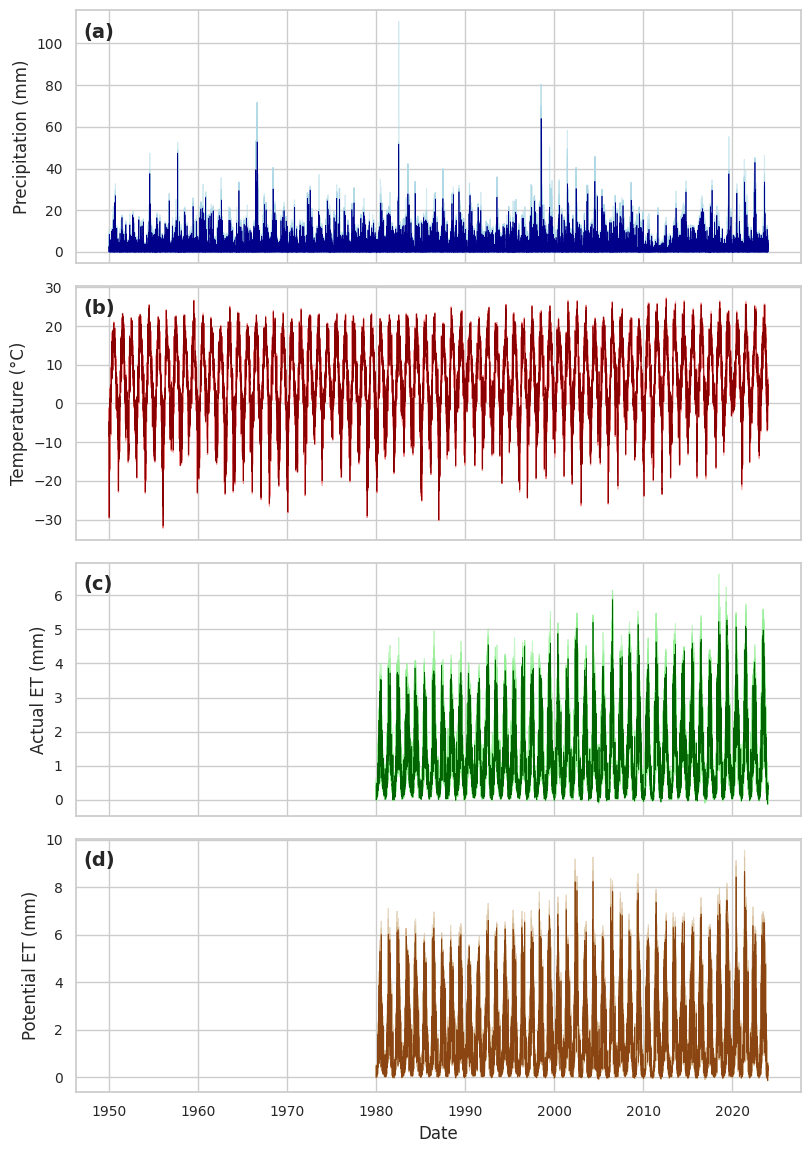

In [ ]:
# Prepare data
df_climate = df.copy()
df_climate['date'] = pd.to_datetime(df_climate['date'])

# Component configuration
components = [
    'precipitation_mm_eobs',
    'temperature_C_eobs',
    'actual_evapotranspiration_mm_gleam',
    'potential_evapotranspiration_mm_gleam'
]

# Custom settings per component
component_settings = {
    'precipitation_mm_eobs': {
        'color_light': 'lightblue',
        'color_dark': 'darkblue',
        'y_label': 'Precipitation (mm)'
    },
    'temperature_C_eobs': {
        'color_light': 'lightcoral',
        'color_dark': 'darkred',
        'y_label': 'Temperature (°C)'
    },
    'actual_evapotranspiration_mm_gleam': {
        'color_light': 'lightgreen',
        'color_dark': 'darkgreen',
        'y_label': 'Actual ET (mm)'
    },
    'potential_evapotranspiration_mm_gleam': {
        'color_light': '#d2b48c',  # tan
        'color_dark': '#8b4513',   # saddlebrown
        'y_label': 'Potential ET (mm)'
    }
}

# Line thickness controls
well_linewidth = 0.8
avg_linewidth = 0.5

# Compute per-date averages
df_avg_list = []
for comp in components:
    subset = df_climate[['date', comp]].dropna()
    avg = subset.groupby('date')[comp].mean().reset_index()
    avg['component'] = comp
    avg.rename(columns={comp: 'value'}, inplace=True)
    df_avg_list.append(avg)

df_avg_melted = pd.concat(df_avg_list, ignore_index=True)
df_avg_melted['well_no'] = 'Average'

# Melt original data
df_melted = df_climate.melt(
    id_vars=['date', 'well_no'],
    value_vars=components,
    var_name='component',
    value_name='value'
).dropna()

# Combine for plotting
df_combined = pd.concat([df_melted, df_avg_melted], ignore_index=True)

# Plotting
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8.27, 11.69), sharex=True)  # A4 portrait size in inches
label_letters = ['(a)', '(b)', '(c)', '(d)']

for ax, comp, label in zip(axes, components, label_letters):
    data = df_combined[df_combined['component'] == comp]
    well_data = data[data['well_no'] != 'Average']
    avg_data = data[data['well_no'] == 'Average']

    color_light = component_settings[comp]['color_light']
    color_dark = component_settings[comp]['color_dark']
    y_label = component_settings[comp]['y_label']

    # Plot well lines
    for _, group in well_data.groupby('well_no'):
        ax.plot(group['date'], group['value'], color=color_light, alpha=0.5, linewidth=well_linewidth)

    # Plot average line
    ax.plot(avg_data['date'], avg_data['value'], color=color_dark, linewidth=avg_linewidth, label='Average')

    # Labeling
    # ax.set_title(comp.replace('_', ' ').title(), fontsize=14)
    ax.set_ylabel(y_label, fontsize=12)
    # ax.legend(loc='upper right', fontsize=10)

    # Add subplot label in upper-left corner
    ax.text(0.01, 0.95, label, transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='left')

# X-axis label for the last plot
axes[-1].set_xlabel("Date", fontsize=12)

# Make tick labels larger
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.savefig("climate_features_timeseries.jpeg", dpi=600)
plt.show()


In [ ]:
# Statistical summary for the selected components
summary_stats = df_climate[components].describe().T  # Transpose for better readability

# Optionally, add median explicitly
summary_stats['median'] = df_climate[components].median()

# Save to CSV
summary_stats.to_csv("climate_features_summary.csv", float_format="%.3f")

summary_stats

,count,mean,std,min,25%,50%,75%,max,median
precipitation_mm_eobs,324344.0,1.580408,3.242028,0.000000,0.000000,0.000000,2.100000,110.500000,0.000000
temperature_C_eobs,324344.0,6.449326,9.086438,-32.230000,0.240000,6.610000,14.120000,27.310000,6.610000
actual_evapotranspiration_mm_gleam,192860.0,1.305131,1.096581,-0.144643,0.350936,0.974092,2.114055,6.629740,0.974092
potential_evapotranspiration_mm_gleam,192860.0,1.766454,1.586217,-0.152749,0.376026,1.267591,2.929489,9.553298,1.267591


### Description and Interpretation of Plots

1. Precipitation (E-OBS)
  * Pattern: Strong short-term variability with occasional extreme events exceeding 60–80 mm/day. No clear long-term trend is visible in annual totals from visual inspection.

  * Seasonality: Precipitation appears to occur year-round, with both small and large events distributed across all months.

  * Implications for hydrology: Large precipitation events are key recharge pulses for groundwater, while smaller events contribute to soil moisture and baseflow. However, extreme outliers may also indicate measurement anomalies.

2. Temperature (E-OBS)
  * Pattern: Highly regular seasonal cycle with peaks in summer (around +20 to +25 °C) and lows in winter (down to –25 °C or colder).

  * Trend: A slight upward shift in winter minima and summer maxima may be present, indicating gradual warming over the decades.

  * Hydrological link: Temperature drives evapotranspiration demand and snowmelt timing, which in turn affect groundwater recharge timing and magnitude. Permafrost limit groundwater recharge as ground ice act as an aquitard.

3. Actual Evapotranspiration (GLEAM)
  * Pattern: Strong annual cycle peaking in summer (~4–5 mm/day) and near zero in winter.

  * Trend: Slight long-term increase in summer peaks is noticeable, likely linked to rising temperatures and possibly vegetation changes.

  * Hydrological link: Represents actual water loss from land to atmosphere, constrained by soil moisture availability. During dry years, even if potential evapotranspiration is high, actual evapotranspiration may be limited.

4. Potential Evapotranspiration (GLEAM)
  * Pattern: Consistent annual cycle with summer peaks around 6–8 mm/day and winter lows near zero.

  * Trend: Gradual increase in summer peak values over time, mirroring the warming trend in temperature data.

  * Hydrological link: Indicates atmospheric demand for water loss. The gap between potential and actual evapotranspiration is informative for assessing drought stress and recharge potential.

### Terrestrial and Groundwater Storage


1. Total Water Storage (TWS) – tws_mm_tavg_gldas

  * Description: Represents the sum of all water stored on and beneath the land surface, including groundwater, soil moisture, snow, canopy water, and surface water bodies, expressed as a storage anomaly (mm) relative to a baseline period.

  * Source: Derived from the GLDAS (Global Land Data Assimilation System), which combines satellite observations, ground measurements, and land-surface modeling to produce spatially consistent water storage estimates.

  * Hydrological significance: Changes in TWS reflect the integrated response of the entire terrestrial water system to precipitation, evapotranspiration, snowmelt, and human water use. Seasonal cycles often correspond to wet and dry periods, while long-term trends can indicate climate change or over-extraction impacts.

2. Groundwater Storage (GWS) – gws_mm_tavg_gldas

  * Description: Represents the groundwater component of total water storage, typically calculated as TWS minus other storages (soil moisture, snow, surface water, and canopy water). Expressed as an anomaly (mm) from a baseline mean.

  * Source: Also from GLDAS, where groundwater storage is estimated using modeled subsurface hydrology and water balance closure methods.

  * Hydrological significance: Changes in GWS indicate groundwater recharge and depletion patterns. Long-term declines may signal over-pumping, persistent drought, or reduced recharge, while increases often occur after sustained wet periods or flooding events.

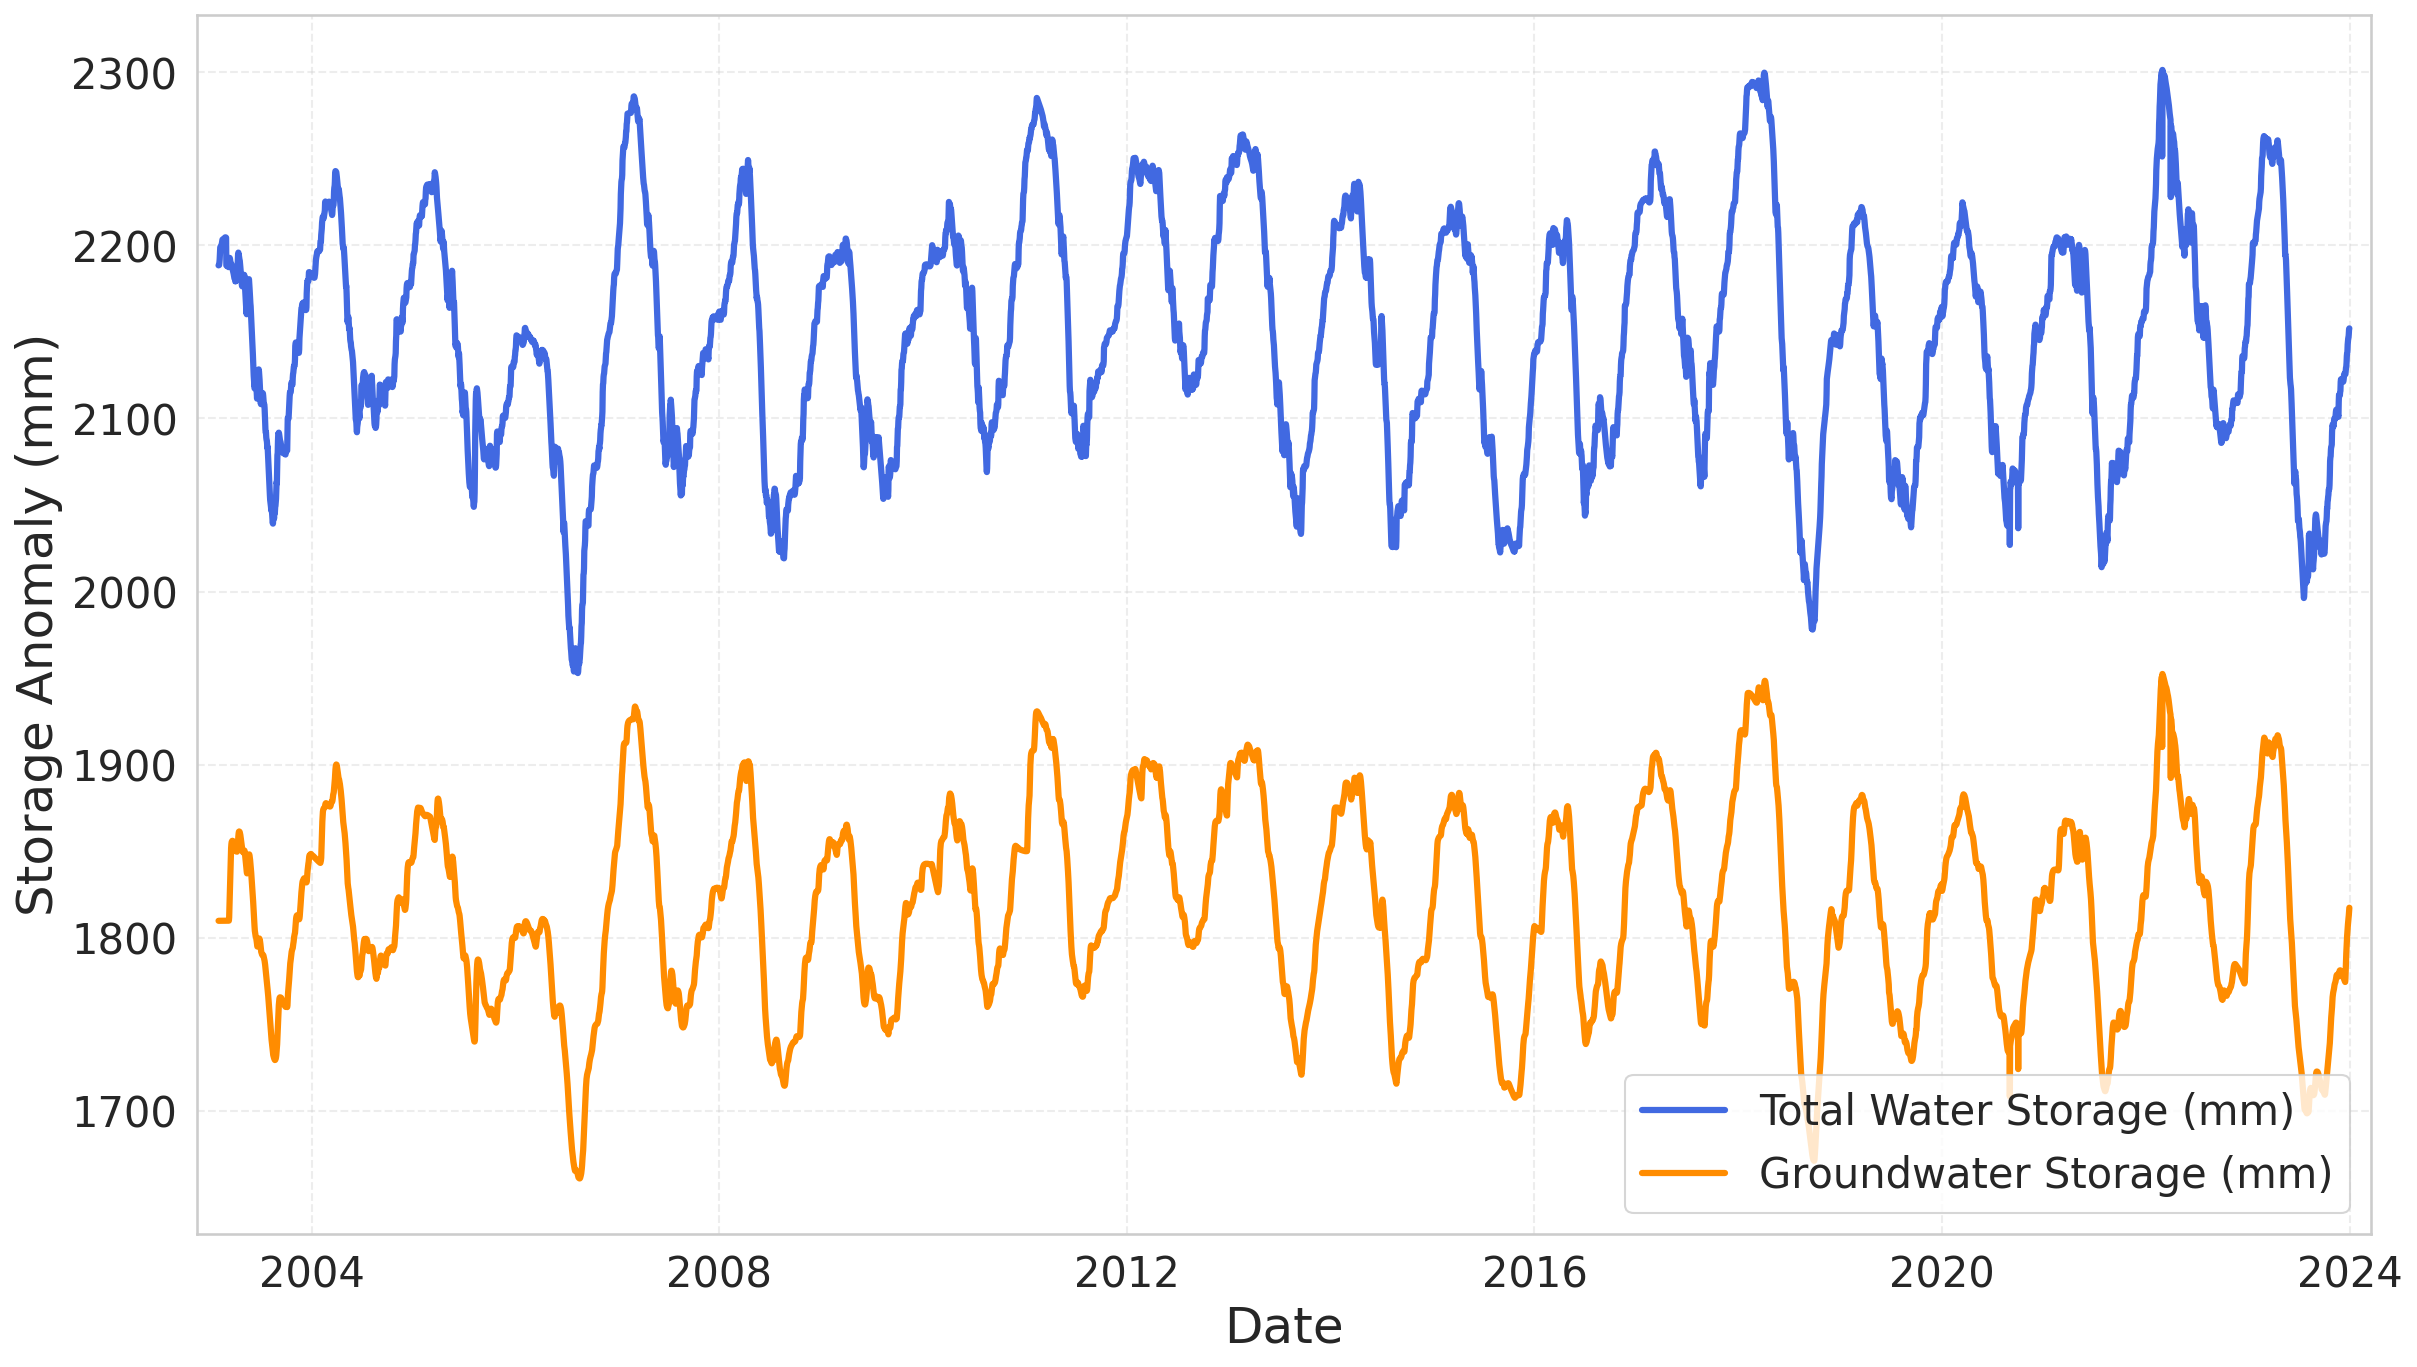

In [ ]:
# STEP 1: Prepare the DataFrame
df_tws = df.copy()
df_tws['date'] = pd.to_datetime(df_tws['date'])

# STEP 2: Define the components to plot
tws_components = {
    'tws_mm_tavg_gldas': {'color': 'royalblue',  'label': 'Total Water Storage (mm)'},
    'gws_mm_tavg_gldas': {'color': 'darkorange', 'label': 'Groundwater Storage (mm)'}
}

# --- Global styling for readability ---
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 13,
    'lines.linewidth': 3,
})

# STEP 3: Create the plot
fig, ax = plt.subplots(figsize=(16, 9), constrained_layout=True)

for comp, settings in tws_components.items():
    subset = df_tws[['date', comp]].dropna()
    avg = subset.groupby('date', as_index=False)[comp].mean()
    ax.plot(avg['date'], avg[comp], label=settings['label'], color=settings['color'])

# Nice date formatting
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# STEP 4: Final plot adjustments
ax.set_xlabel('Date', fontsize=24)
ax.set_ylabel('Storage Anomaly (mm)', fontsize=24)
# ax.set_title('Average Total and Groundwater Storage Over Time', pad=12)
ax.grid(True, which='major', linestyle='--', alpha=0.35)
ax.legend(frameon=True, ncol=1, fontsize=20, loc='lower right')
ax.margins(x=0.01)

plt.savefig("tws_gws_timeseries.jpeg", dpi=600)
plt.show()

### Description and Interpretation of Plots
Strong seasonality:

* Both TWS and GWS show a clear annual cycle — peaks likely occur after seasonal recharge (spring snowmelt or wet season rainfall), and troughs occur after prolonged dry periods or high evapotranspiration in summer/autumn.

* The amplitude of the seasonal cycle is slightly smaller in GWS than in TWS, reflecting the buffering role of groundwater compared to faster-changing surface and soil water components.

Interannual variability:

* Some years show notably higher peaks (e.g., around 2005, 2010, 2017, 2021), possibly due to wetter-than-average years or above-average snowmelt recharge.

* Some troughs (e.g., 2006, 2015, 2019, 2022) indicate potential drought years or periods of low recharge.

Long-term trend:

* No strong monotonic increase or decrease is immediately obvious, but there is variability that may correspond to multi-year wet/dry cycles rather than a steady trend.

* Slight decreases in low points over time could hint at gradual depletion, though this would require statistical testing to confirm.

Relationship between TWS and GWS:

* GWS tracks the seasonal and interannual patterns of TWS closely, but with consistently lower magnitude (expected, since TWS includes other storage forms).

* In dry years, GWS declines more slowly than TWS, suggesting groundwater acts as a storage buffer during droughts.



### Scatter Plots of Groundwater level vs GWS and TWS

Assessing Physical Relationships

* Scatter plots help visualize how local groundwater level observations (m ASL) relate to large-scale modeled storage anomalies from GLDAS.

* A strong linear relationship suggests that the model-derived Groundwater Storage (GWS) or Total Water Storage (TWS) effectively captures the dynamics observed in the field.

Model Validation and Confidence

* By comparing field measurements against model outputs, we can evaluate the reliability of remote sensing and modeled products for regional or local hydrological studies.

* High R² values in these plots indicate good agreement, giving more confidence to use GWS/TWS for wells lacking long-term measurements.

Identifying Regional Differences

* Grouping wells by regional stage and comparing the scatter patterns can reveal spatial variability in groundwater–storage relationships.

* This helps determine whether certain areas respond differently to climate forcing due to geology, aquifer properties, or human impacts.

Detecting Data Issues

* Scatter plots can quickly reveal outliers, clusters, or inconsistent slopes that may indicate sensor errors, incorrect data processing, or mismatched time series.

* Supporting Predictive Modeling

Establishing strong empirical relationships between GW level and GWS/TWS is valuable for developing predictive models, particularly where local measurements are sparse but satellite/model products are available.

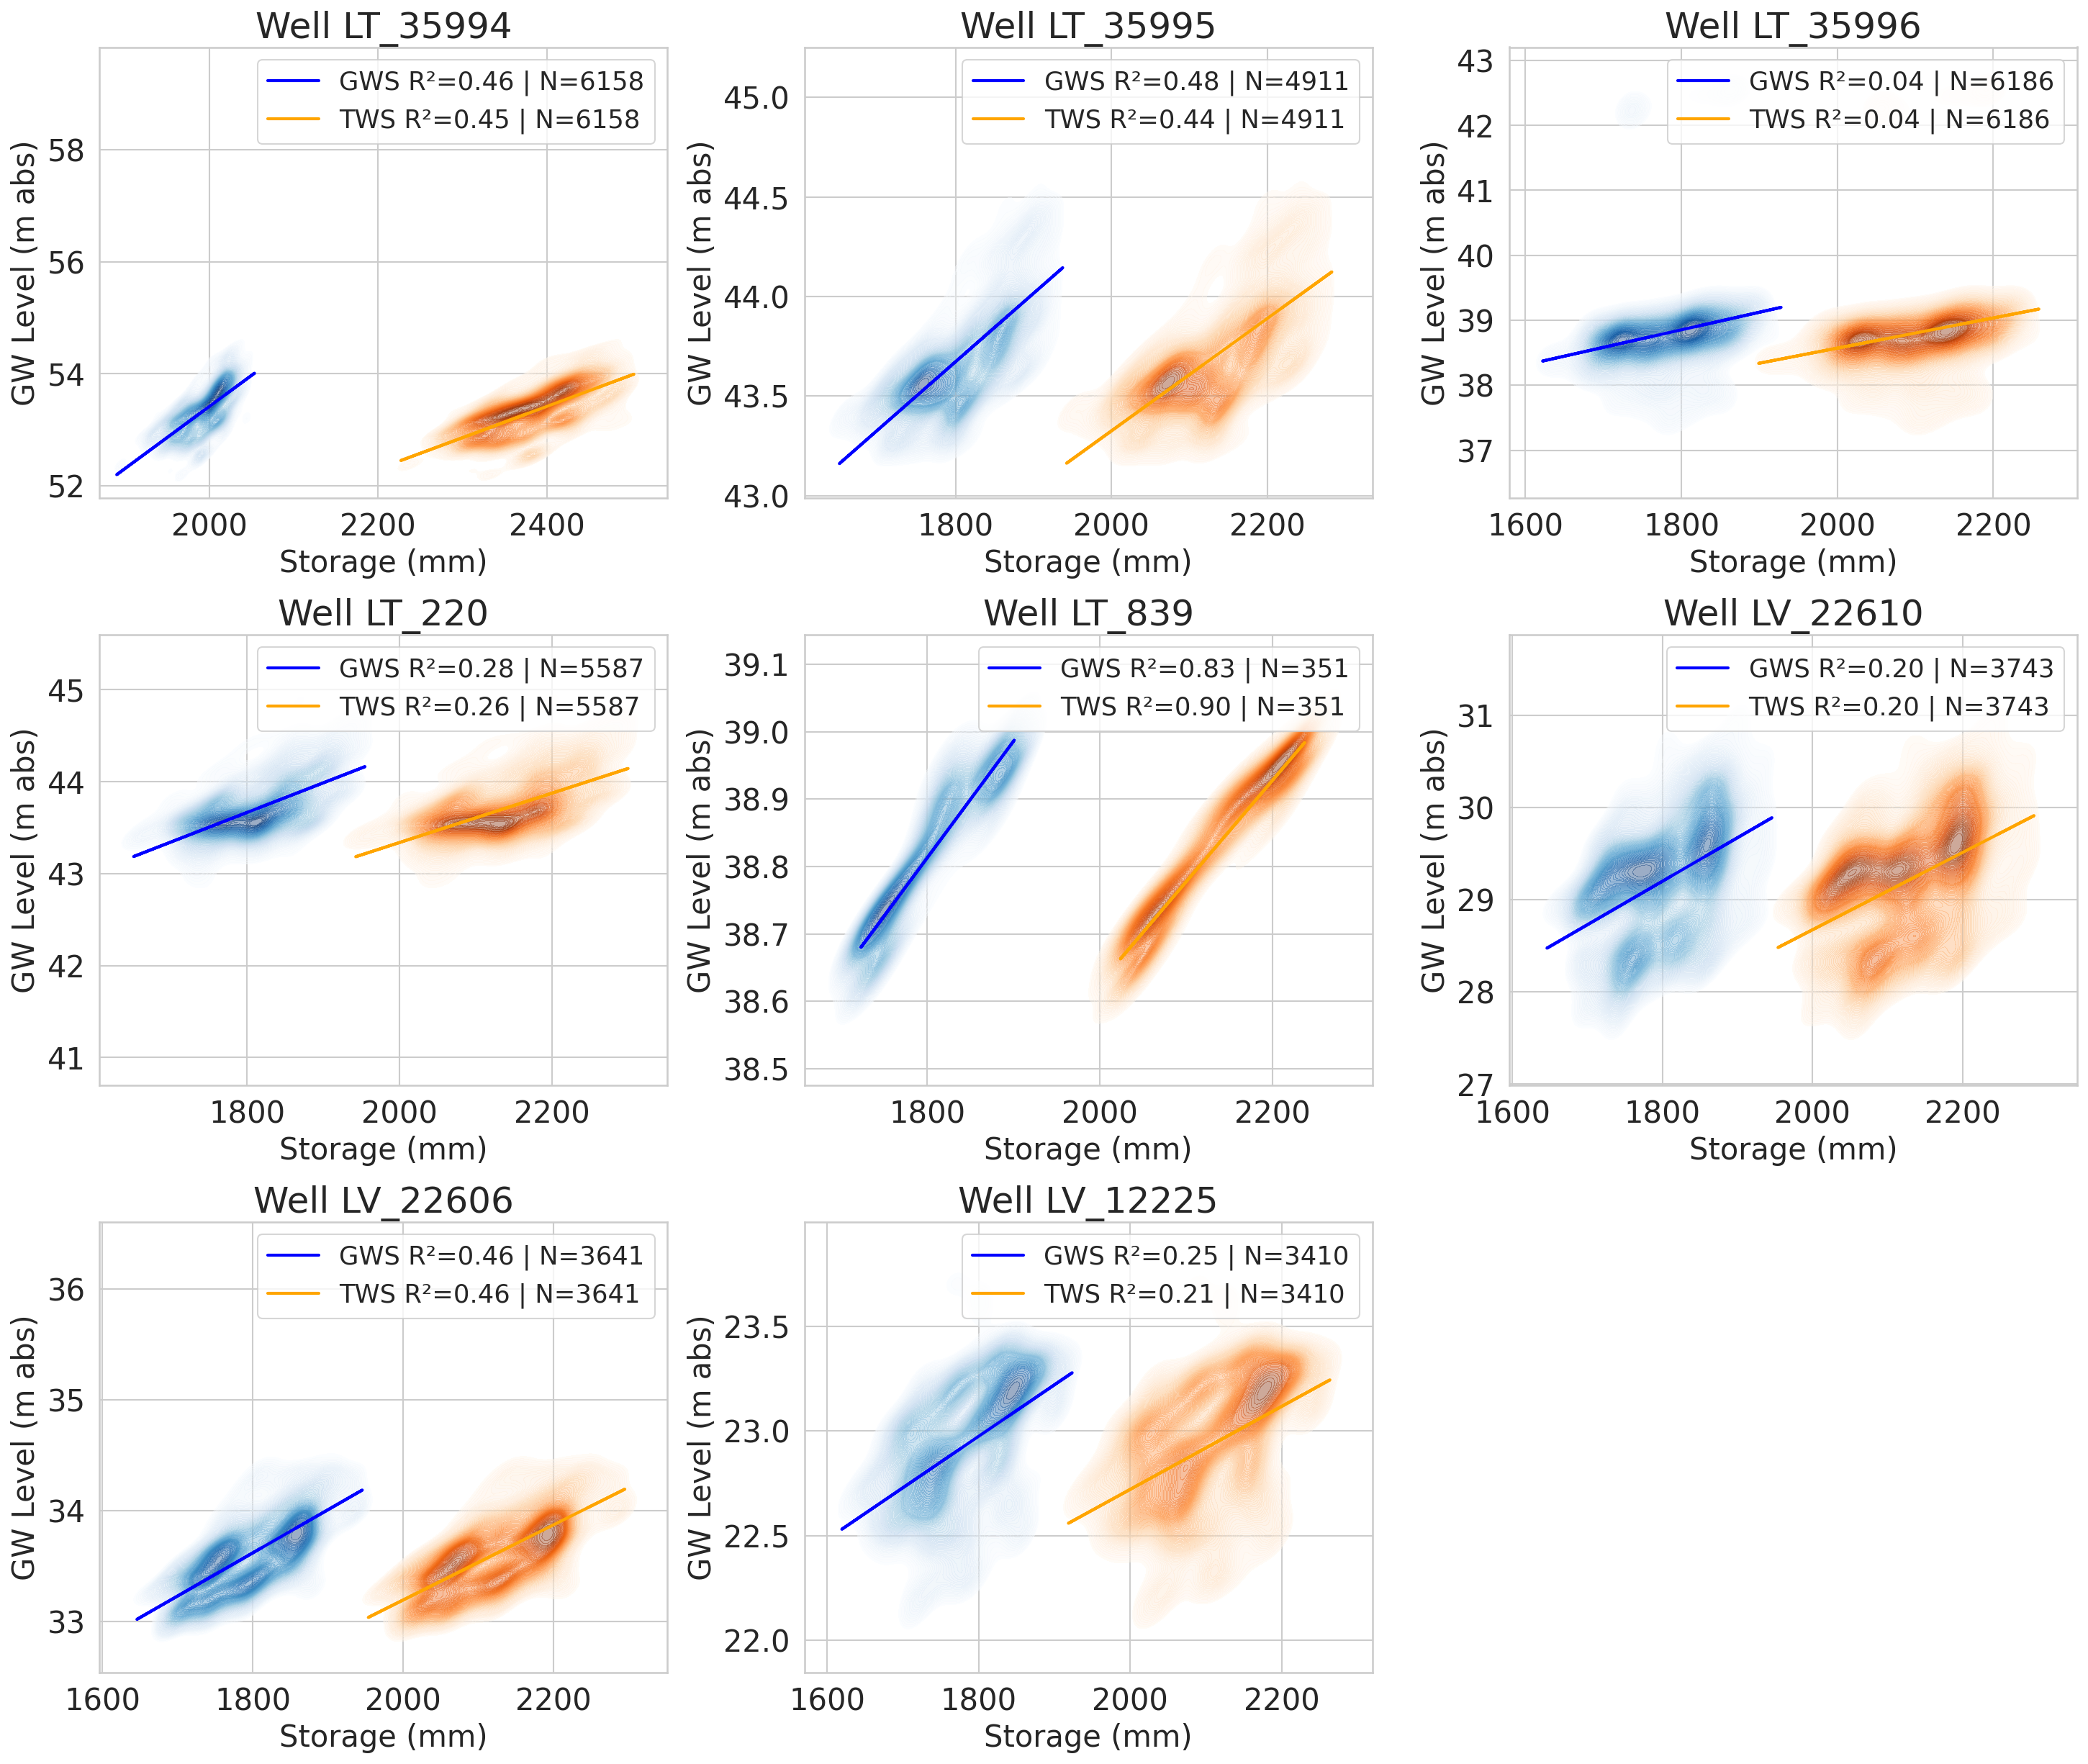

In [ ]:
# STEP 1: Prepare data
df['date'] = pd.to_datetime(df['date'])
df_scatter = df[['well_no', 'regional_stage', 'date', 'gw_level_m_asl',
                 'gws_mm_tavg_gldas', 'tws_mm_tavg_gldas']].dropna()

# ---- Global font sizes for better visibility ----
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 17
})

# STEP 2: Set up plot grid (3 columns)
wells = df_scatter['well_no'].unique()
ncols = 3
nrows = int(np.ceil(len(wells) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(ncols * 6.5, nrows * 5.5),
    sharex=False,
    sharey=False
)
axes = np.array(axes).reshape(-1)  # flatten robustly

r2_records = []

# STEP 3: Plot per well
for idx, well in enumerate(wells):
    ax = axes[idx]
    data = df_scatter[df_scatter['well_no'] == well]
    x_gws = data['gws_mm_tavg_gldas'].values
    x_tws = data['tws_mm_tavg_gldas'].values
    y = data['gw_level_m_asl'].values
    n_measurements = data['date'].nunique()

    # Regressions
    model_gws = LinearRegression().fit(x_gws.reshape(-1, 1), y)
    model_tws = LinearRegression().fit(x_tws.reshape(-1, 1), y)
    y_pred_gws = model_gws.predict(x_gws.reshape(-1, 1))
    y_pred_tws = model_tws.predict(x_tws.reshape(-1, 1))
    r2_gws = r2_score(y, y_pred_gws)
    r2_tws = r2_score(y, y_pred_tws)

    # Store R² and count
    stage = data['regional_stage'].iloc[0]
    r2_records.append({
        'well_no': well,
        'regional_stage': stage,
        'R2_GWS': r2_gws,
        'R2_TWS': r2_tws,
        'n_measurements': n_measurements
    })

    # KDE plots
    sns.kdeplot(x=x_gws, y=y, fill=True, cmap="Blues", thresh=0.05, levels=100, ax=ax, alpha=0.4)
    sns.kdeplot(x=x_tws, y=y, fill=True, cmap="Oranges", thresh=0.05, levels=100, ax=ax, alpha=0.4)

    # Trendlines
    ax.plot(x_gws, y_pred_gws, color='blue', linewidth=2,
            label=f'GWS R²={r2_gws:.2f} | N={n_measurements}')
    ax.plot(x_tws, y_pred_tws, color='orange', linewidth=2,
            label=f'TWS R²={r2_tws:.2f} | N={n_measurements}')

    ax.set_title(f'Well {well}', fontsize=24)
    ax.set_xlabel('Storage (mm)', fontsize=20)
    ax.set_ylabel('GW Level (m abs)', fontsize=20)
    ax.legend()

# STEP 4: Remove unused axes (if any)
for k in range(len(wells), len(axes)):
    fig.delaxes(axes[k])

plt.tight_layout()
plt.savefig("level_vs_gws_tws.jpeg", dpi=600)
plt.show()

In [ ]:
# STEP 6: R² Summary Table
r2_df = pd.DataFrame(r2_records)

# Group by regional_stage and well_no with average R² and total measurement count
r2_summary = r2_df.groupby(['regional_stage', 'well_no']).agg({
    'R2_GWS': 'mean',
    'R2_TWS': 'mean',
    'n_measurements': 'sum'
}).round(2)
r2_summary.to_csv('level_vs_gws_tws_statistics.csv')
r2_summary

R2_GWS  R2_TWS  n_measurements
regional_stage well_no                                 
Daugava        LT_35994    0.46    0.45            6158
               LT_839      0.83    0.90             351
               LV_12225    0.25    0.21            3410
Dubnik         LT_220      0.28    0.26            5587
               LT_35995    0.48    0.44            4911
               LT_35996    0.04    0.04            6186
               LV_22606    0.46    0.46            3641
               LV_22610    0.20    0.20            3743

### Scatter Plot Description and Interpretation
* Each subplot shows the relationship between observed groundwater level (m ASL) and storage anomalies from GLDAS, with blue representing GWS and orange representing TWS.

* R² values indicate the proportion of variation in groundwater levels explained by the storage variable.

* The number of measurements (N) varies widely — some wells have dense, long-term records (N > 6000), while others have sparse records (N ~ 350).

Well-by-well interpretation
* High correlation wells
  * LT_839: GWS R² = 0.83, TWS R² = 0.90 — exceptionally strong linear relationships. Indicates that both groundwater and total water storage anomalies closely track local groundwater levels. Small N (351) means this could be from a short but very consistent record.

* Moderate correlation wells
  * LT_35994 (GWS R² = 0.46, TWS R² = 0.45)

  * LT_35995 (GWS R² = 0.48, TWS R² = 0.44)

  * LV_22606 (GWS R² = 0.46, TWS R² = 0.46)

  These wells show decent predictive strength — about half of groundwater level variation is explained by storage changes. Useful for model calibration, though local factors (pumping, geology) may cause additional variability.

* Low correlation wells
  * LT_35996 (GWS R² = 0.04, TWS R² = 0.04)

  * LV_22610 (GWS R² = 0.20, TWS R² = 0.20)

  * LV_12225 (GWS R² = 0.25, TWS R² = 0.21)

  * LT_220 (GWS R² = 0.28, TWS R² = 0.26)

* Weak to very weak relationships — storage anomalies explain little of the observed variation.

  * Possible reasons: localised influences (pumping, surface–groundwater disconnection), aquifer heterogeneity, or measurement inconsistencies.

Key takeaways
* Spatial variability in correlation strength — Some wells align closely with GWS/TWS data, others show weak or no correlation, indicating that large-scale modeled storage products are not equally representative everywhere.

* GWS vs TWS performance — In most wells, GWS and TWS have similar R² values, though in a few cases (e.g., LT_839) TWS outperforms GWS.

* Potential for predictive modeling — Wells with moderate-to-high R² could be candidates for ML models that use GLDAS storage variables to estimate groundwater levels. Low R² wells might require additional local data inputs or different modeling approaches.

* Measurement density impact — High-N wells likely capture more variability and noise, while low-N wells (e.g., LT_839) can show artificially high correlations if measurements are limited to consistent hydrological conditions.

### Summary and Main Insights
Data Preparation and Requirements for Groundwater Level & Sinkhole Risk ML Modeling
1. Groundwater Level Data Quality
  * Hydrographs reveal gaps in monitoring records (straight-line connections between distant points), spikes likely caused by equipment maintenance or logging errors, and wells with data predating 2003 that cannot be used for modeling due to missing predictor variables.

  * Action: Missing values must be imputed and erroneous spikes removed through preprocessing. Wells with incomplete overlap with climate and storage datasets should be discarded for machine learning.

2. Climate Forcing Parameters

  * Precipitation (E-OBS) shows high variability with occasional extreme events, providing recharge pulses for groundwater.

  * Temperature (E-OBS) exhibits strong seasonal cycles and gradual warming, influencing evapotranspiration demand and permafrost formation.

  * Actual Evapotranspiration (AET) and Potential Evapotranspiration (PET) (GLEAM) display pronounced summer peaks and winter lows, with PET > AET, indicating water-limited periods.

  Relevance: These parameters are essential inputs for modeling groundwater dynamics, as they govern recharge, storage depletion, and drought stress.

3. Storage Anomalies from GLDAS

  * Total Water Storage (TWS) integrates all terrestrial water components.

  * Groundwater Storage (GWS) isolates the subsurface component and shows similar seasonal and interannual variability to TWS, but with smaller amplitude.

  * Both TWS and GWS exhibit annual recharge–depletion cycles and multi-year variability, closely linked to climate forcing.

  Relevance: GWS and TWS provide large-scale hydrological context, filling spatial and temporal gaps where direct groundwater measurements are unavailable.

4. Groundwater Level vs GWS/TWS Relationships

  * Scatter plot analysis shows spatial variability in correlation strength between observed groundwater levels and GLDAS-derived storage anomalies:

  * Strong correlation (R² ≥ 0.8) in a few wells, indicating close coupling between modeled storage and local groundwater levels.

  * Moderate correlation (R² ≈ 0.4–0.5) in several wells, suggesting that GWS/TWS can partially explain level fluctuations.

  * Weak correlation (R² < 0.3) in others, likely due to local aquifer heterogeneity, pumping, or surface–groundwater disconnection.

 Relevance: Wells with higher R² are more suitable for predictive modeling, while low-R² wells may require additional local predictors.

5. Requirements for Successful ML Modeling

  * Aligned datasets: Groundwater level records must be temporally matched with climate and storage parameters — at least from 2003 onward.

Data preprocessing:

  * Imputation for missing groundwater levels.

  * Removal of measurement spikes and anomalous values.

  * Normalization or seasonal decomposition of predictors to capture cyclic behavior.

Predictor set:

  * Climate forcing (precipitation, temperature, AET, PET).

  * Storage anomalies (GWS, TWS).

  * Seasonal features.

Application to Sinkhole Risk: Changes in groundwater storage and levels can contribute to sinkhole formation in karst regions. ML models combining GW level trends, storage changes, and climate drivers can help forecast elevated sinkhole risk periods.